# Residual-Based Adaptive Sampling

This notebook continues the optimization story from notebook `04`.

Once the loss terms are chosen, the next question is where the PDE should be enforced. A PINN does not make equal progress everywhere in the domain, so a fixed sampling rule can waste collocation budget on easy regions while underserving the hard ones.

## Notebook Contract

- **Status:** core-executable
- **Research question:** With the same collocation budget, can residual-based resampling outperform uniform resampling on a boundary-layer Poisson problem?
- **Canonical problem:** 1D Poisson equation with an exact solution that changes sharply near `x = 1`
- **Main comparison:** uniform random refresh vs residual-based adaptive refresh, both with the same anchor points and the same model initialization

## Why This Notebook Exists

Notebook `04` showed that optimization can fail even when the objective is mathematically correct. This notebook asks a complementary question: what if the objective is fine, but we keep asking the network to satisfy the PDE in the wrong places?

There is an important subtlety here. In 1D, a fixed uniform grid is already a fairly strong baseline, so it does not isolate the sampling policy very cleanly. To study the sampling policy itself, we compare two **refreshing** strategies under the same interior budget:

- **uniform refresh:** redraw the flexible collocation points uniformly,
- **adaptive refresh:** redraw them using the current residual as an importance score.

Both strategies keep the same small set of anchor points so the whole domain never disappears from training.

In [1]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy: 2.4.3
PyTorch: 2.10.0+cu128
Device: cpu


## Canonical PDE

We stay with a 1D Poisson problem,

$$
- u''(x) = f(x), \qquad x \in (0, 1), \qquad u(0) = u(1) = 0,
$$

but choose an exact solution with a **right boundary layer**:

$$
u^*(x) = x - \frac{e^{\beta x} - 1}{e^{\beta} - 1}, \qquad \beta = 12.
$$

This gives the forcing term

$$
f(x) = \frac{\beta^2 e^{\beta x}}{e^{\beta} - 1}.
$$

The solution stays relatively gentle across most of the domain and then changes sharply near $x = 1$. That makes it a good teaching benchmark for adaptive sampling: a uniform rule can miss the hard region, while a residual-based rule has a reason to move points there.

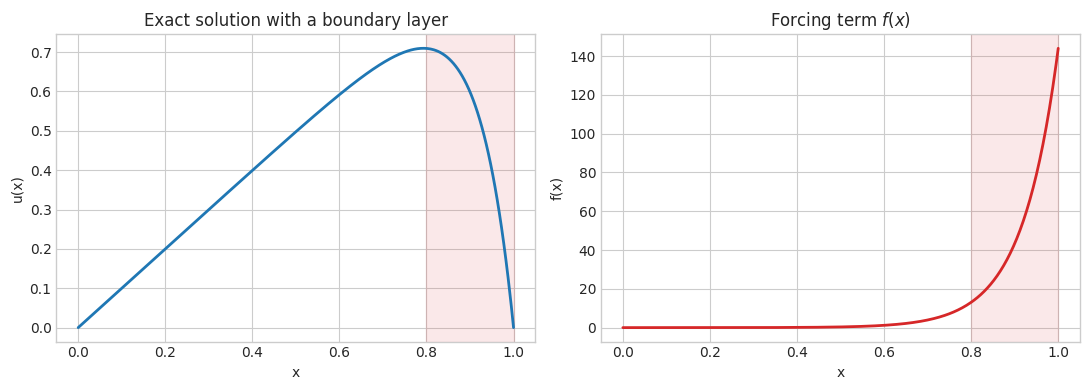

In [2]:
beta = 12.0
normalizer_np = np.exp(beta) - 1.0
normalizer_torch = torch.exp(torch.tensor(beta, device=device)) - 1.0


def exact_solution_np(x: np.ndarray) -> np.ndarray:
    return x - (np.exp(beta * x) - 1.0) / normalizer_np


def forcing_np(x: np.ndarray) -> np.ndarray:
    return (beta ** 2) * np.exp(beta * x) / normalizer_np


def exact_solution_torch(x: torch.Tensor) -> torch.Tensor:
    return x - (torch.exp(beta * x) - 1.0) / normalizer_torch


def forcing_torch(x: torch.Tensor) -> torch.Tensor:
    return (beta ** 2) * torch.exp(beta * x) / normalizer_torch


x_plot = np.linspace(0.0, 1.0, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_plot, exact_solution_np(x_plot), color="tab:blue", linewidth=2)
axes[0].axvspan(0.8, 1.0, color="tab:red", alpha=0.10)
axes[0].set_title("Exact solution with a boundary layer")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")

axes[1].plot(x_plot, forcing_np(x_plot), color="tab:red", linewidth=2)
axes[1].axvspan(0.8, 1.0, color="tab:red", alpha=0.10)
axes[1].set_title("Forcing term $f(x)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")

plt.tight_layout()
plt.show()

## Sampling Rules

The two samplers share the same total interior budget and the same `4` anchor points.

For the **uniform** sampler, the remaining points are redrawn from a uniform distribution over `(0, 1)`.

For the **adaptive** sampler, we first warm up with uniform samples, then build a dense candidate pool and compute the current residual on that pool. The refresh probabilities are

$$
p_i \propto |r_\theta(x_i)|^{\alpha} + \varepsilon,
$$

where $r_\theta(x)$ is the current PDE residual, $\alpha$ controls how sharply we focus on hard regions, and $\varepsilon$ prevents any candidate point from having zero probability.

This is a practical version of residual-based adaptive sampling: keep a small global scaffold, then spend the flexible budget where the model is still struggling.

In [3]:
def gradient(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def second_derivative(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return gradient(gradient(y, x), x)


def make_anchor_points(anchor_count: int) -> torch.Tensor:
    return torch.linspace(0.0, 1.0, anchor_count + 2, device=device).view(-1, 1)[1:-1]


def sample_uniform_points(num_points: int, anchor_count: int) -> torch.Tensor:
    if num_points <= anchor_count:
        raise ValueError("num_points must be larger than anchor_count.")
    x_random = torch.rand(num_points - anchor_count, 1, device=device)
    x_all = torch.cat([make_anchor_points(anchor_count), x_random], dim=0)
    x_all, _ = torch.sort(x_all.squeeze())
    return x_all.view(-1, 1).clone().detach().requires_grad_(True)


class VanillaPINN(nn.Module):
    def __init__(self, width: int = 20, depth: int = 2):
        super().__init__()
        layers: list[nn.Module] = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def pinn_losses(
    model: nn.Module,
    x_interior: torch.Tensor,
    x_boundary: torch.Tensor,
    bc_weight: float,
) -> dict[str, torch.Tensor]:
    u_interior = model(x_interior)
    residual = -second_derivative(u_interior, x_interior) - forcing_torch(x_interior)
    physics_loss = torch.mean(residual.square())
    boundary_values = model(x_boundary)
    boundary_loss = torch.mean(boundary_values.square())
    total_loss = physics_loss + bc_weight * boundary_loss
    return {
        "total": total_loss,
        "physics": physics_loss,
        "boundary": boundary_loss,
        "residual": residual,
    }


def sample_adaptive_points(
    model: nn.Module,
    x_boundary: torch.Tensor,
    config: dict[str, float | int],
):
    x_candidate = torch.linspace(0.0, 1.0, config["candidate_pool"], device=device).view(-1, 1)
    x_candidate = x_candidate.clone().detach().requires_grad_(True)
    losses = pinn_losses(
        model=model,
        x_interior=x_candidate,
        x_boundary=x_boundary,
        bc_weight=config["bc_weight"],
    )
    residual_abs = losses["residual"].detach().abs().squeeze()
    weights = residual_abs.pow(config["sample_alpha"]) + config["sample_floor"]
    weights = weights / weights.sum()

    sample_count = config["num_interior"] - config["anchor_count"]
    indices = torch.multinomial(weights, num_samples=sample_count, replacement=False)
    sampled_x = x_candidate.detach()[indices]
    x_all = torch.cat([make_anchor_points(config["anchor_count"]), sampled_x], dim=0)
    x_all, _ = torch.sort(x_all.squeeze())

    diagnostics = {
        "candidate_x": x_candidate.detach().cpu().numpy().ravel(),
        "residual_abs": residual_abs.cpu().numpy(),
        "weights": weights.detach().cpu().numpy(),
        "sampled_x": sampled_x.detach().cpu().numpy().ravel(),
    }
    return x_all.view(-1, 1).clone().detach().requires_grad_(True), diagnostics

In [4]:
def evaluate_model(model: nn.Module, x_boundary: torch.Tensor, layer_start: float = 0.8):
    x_eval = torch.linspace(0.0, 1.0, 401, device=device).view(-1, 1)
    x_eval = x_eval.clone().detach().requires_grad_(True)

    u_pred = model(x_eval)
    u_exact = exact_solution_torch(x_eval)
    residual = -second_derivative(u_pred, x_eval) - forcing_torch(x_eval)
    boundary_values = model(x_boundary)
    abs_error = torch.abs(u_pred - u_exact)
    layer_mask = x_eval.squeeze() >= layer_start

    metrics = {
        "max_error": abs_error.max().detach().item(),
        "l2_error": torch.sqrt(torch.mean((u_pred - u_exact).square())).detach().item(),
        "mean_abs_residual": torch.mean(torch.abs(residual)).detach().item(),
        "mean_abs_boundary_violation": torch.mean(torch.abs(boundary_values)).detach().item(),
        "layer_l2_error": torch.sqrt(torch.mean((u_pred[layer_mask] - u_exact[layer_mask]).square())).detach().item(),
        "layer_max_error": torch.max(abs_error[layer_mask]).detach().item(),
    }
    fields = {
        "x": x_eval.detach().cpu().numpy().ravel(),
        "u_pred": u_pred.detach().cpu().numpy().ravel(),
        "u_exact": u_exact.detach().cpu().numpy().ravel(),
        "residual": residual.detach().cpu().numpy().ravel(),
        "abs_error": abs_error.detach().cpu().numpy().ravel(),
    }
    return metrics, fields

## Training Setup

We keep the experiment intentionally small and comparable:

- `16` interior collocation points per refresh,
- `4` fixed anchor points,
- a width-`20`, depth-`2` MLP,
- Adam with learning rate `1e-3`,
- `1800` optimization steps,
- refresh every `150` steps,
- adaptive sampling only after a `300`-step warmup,
- residual power `\alpha = 0.8`.

The uniform and adaptive runs share the same network initialization. The only difference is how the non-anchor collocation points are refreshed.

In [5]:
config = {
    "num_interior": 16,
    "anchor_count": 4,
    "width": 20,
    "depth": 2,
    "learning_rate": 1e-3,
    "bc_weight": 50.0,
    "steps": 1800,
    "refresh_every": 150,
    "log_every": 150,
    "warmup_steps": 300,
    "candidate_pool": 2048,
    "sample_alpha": 0.8,
    "sample_floor": 1e-4,
    "sampling_seed": 7,
}

x_boundary = torch.tensor([[0.0], [1.0]], device=device)

torch.manual_seed(7)
base_model = VanillaPINN(width=config["width"], depth=config["depth"]).to(device)
initial_state = deepcopy(base_model.state_dict())


def train_model(mode: str):
    torch.manual_seed(config["sampling_seed"])
    model = VanillaPINN(width=config["width"], depth=config["depth"]).to(device)
    model.load_state_dict(deepcopy(initial_state))
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

    history = {
        "step": [],
        "total": [],
        "physics": [],
        "boundary": [],
        "l2_error": [],
        "max_error": [],
        "mean_abs_residual": [],
        "mean_abs_boundary_violation": [],
        "layer_l2_error": [],
        "layer_max_error": [],
        "refresh_step": [],
        "x_points": [],
        "last_sampling": None,
    }

    x_interior = sample_uniform_points(config["num_interior"], config["anchor_count"])
    history["refresh_step"].append(0)
    history["x_points"].append(x_interior.detach().cpu().numpy().ravel())

    def record(step: int) -> None:
        losses = pinn_losses(
            model=model,
            x_interior=x_interior,
            x_boundary=x_boundary,
            bc_weight=config["bc_weight"],
        )
        metrics, _ = evaluate_model(model=model, x_boundary=x_boundary)
        history["step"].append(step)
        history["total"].append(losses["total"].detach().item())
        history["physics"].append(losses["physics"].detach().item())
        history["boundary"].append(losses["boundary"].detach().item())
        history["l2_error"].append(metrics["l2_error"])
        history["max_error"].append(metrics["max_error"])
        history["mean_abs_residual"].append(metrics["mean_abs_residual"])
        history["mean_abs_boundary_violation"].append(metrics["mean_abs_boundary_violation"])
        history["layer_l2_error"].append(metrics["layer_l2_error"])
        history["layer_max_error"].append(metrics["layer_max_error"])
        print(
            f"[{mode}] step={step:4d} | total={history['total'][-1]:.3e} | "
            f"L2={history['l2_error'][-1]:.3e} | layer L2={history['layer_l2_error'][-1]:.3e} | "
            f"mean |res|={history['mean_abs_residual'][-1]:.3e}"
        )

    record(step=0)
    for step in range(1, config["steps"] + 1):
        if step == 1 or step % config["refresh_every"] == 1:
            if mode == "uniform":
                x_interior = sample_uniform_points(config["num_interior"], config["anchor_count"])
                history["last_sampling"] = None
            elif mode == "adaptive":
                if step <= config["warmup_steps"]:
                    x_interior = sample_uniform_points(config["num_interior"], config["anchor_count"])
                    history["last_sampling"] = None
                else:
                    x_interior, diagnostics = sample_adaptive_points(
                        model=model,
                        x_boundary=x_boundary,
                        config=config,
                    )
                    history["last_sampling"] = diagnostics
            else:
                raise ValueError(f"Unknown mode: {mode}")

            history["refresh_step"].append(step)
            history["x_points"].append(x_interior.detach().cpu().numpy().ravel())

        optimizer.zero_grad()
        losses = pinn_losses(
            model=model,
            x_interior=x_interior,
            x_boundary=x_boundary,
            bc_weight=config["bc_weight"],
        )
        losses["total"].backward()
        optimizer.step()

        if step % config["log_every"] == 0 or step == config["steps"]:
            record(step=step)

    history["mode"] = mode
    return model, history


uniform_model, uniform_history = train_model(mode="uniform")
adaptive_model, adaptive_history = train_model(mode="adaptive")

[uniform] step=   0 | total=2.474e+02 | L2=3.514e-01 | layer L2=4.019e-01 | mean |res|=1.215e+01
[uniform] step= 150 | total=2.239e+02 | L2=2.361e-01 | layer L2=2.579e-01 | mean |res|=1.130e+01
[uniform] step= 300 | total=1.659e+01 | L2=1.417e-01 | layer L2=5.683e-02 | mean |res|=4.555e+00
[uniform] step= 450 | total=9.645e-01 | L2=7.570e-03 | layer L2=5.294e-03 | mean |res|=2.491e+00
[uniform] step= 600 | total=2.836e-02 | L2=1.985e-02 | layer L2=3.863e-02 | mean |res|=2.609e+00
[uniform] step= 750 | total=1.246e+00 | L2=3.472e-02 | layer L2=3.226e-02 | mean |res|=1.482e+00
[uniform] step= 900 | total=1.481e-01 | L2=6.115e-03 | layer L2=9.026e-03 | mean |res|=1.117e+00
[uniform] step=1050 | total=1.214e-01 | L2=4.754e-03 | layer L2=6.069e-03 | mean |res|=1.026e+00
[uniform] step=1200 | total=6.525e-02 | L2=7.171e-03 | layer L2=6.523e-03 | mean |res|=1.028e+00
[uniform] step=1350 | total=1.795e-02 | L2=9.085e-02 | layer L2=1.269e-01 | mean |res|=2.713e+00
[uniform] step=1500 | total=1.

## Final Evaluation

We report both full-domain and boundary-layer metrics. The layer-specific numbers matter because the right boundary is exactly where the solution is hardest and where adaptive sampling should concentrate its effort.

The most important question is not whether the adaptive sampler makes every scalar metric look better at every intermediate checkpoint. The important question is whether it spends a scarce collocation budget more effectively in the hard region.

In [6]:
uniform_metrics, uniform_fields = evaluate_model(uniform_model, x_boundary=x_boundary)
adaptive_metrics, adaptive_fields = evaluate_model(adaptive_model, x_boundary=x_boundary)

for label, metrics in [("UNIFORM", uniform_metrics), ("ADAPTIVE", adaptive_metrics)]:
    print(label)
    print(f"  L2 error:                 {metrics['l2_error']:.3e}")
    print(f"  max error:                {metrics['max_error']:.3e}")
    print(f"  mean abs residual:        {metrics['mean_abs_residual']:.3e}")
    print(f"  mean abs BC violation:    {metrics['mean_abs_boundary_violation']:.3e}")
    print(f"  boundary-layer L2 error:  {metrics['layer_l2_error']:.3e}")
    print(f"  boundary-layer max error: {metrics['layer_max_error']:.3e}")

UNIFORM
  L2 error:                 2.195e-02
  max error:                3.167e-02
  mean abs residual:        6.562e-01
  mean abs BC violation:    8.117e-04
  boundary-layer L2 error:  2.327e-02
  boundary-layer max error: 3.167e-02
ADAPTIVE
  L2 error:                 4.980e-03
  max error:                7.457e-03
  mean abs residual:        2.176e-01
  mean abs BC violation:    2.768e-04
  boundary-layer L2 error:  5.962e-03
  boundary-layer max error: 7.457e-03


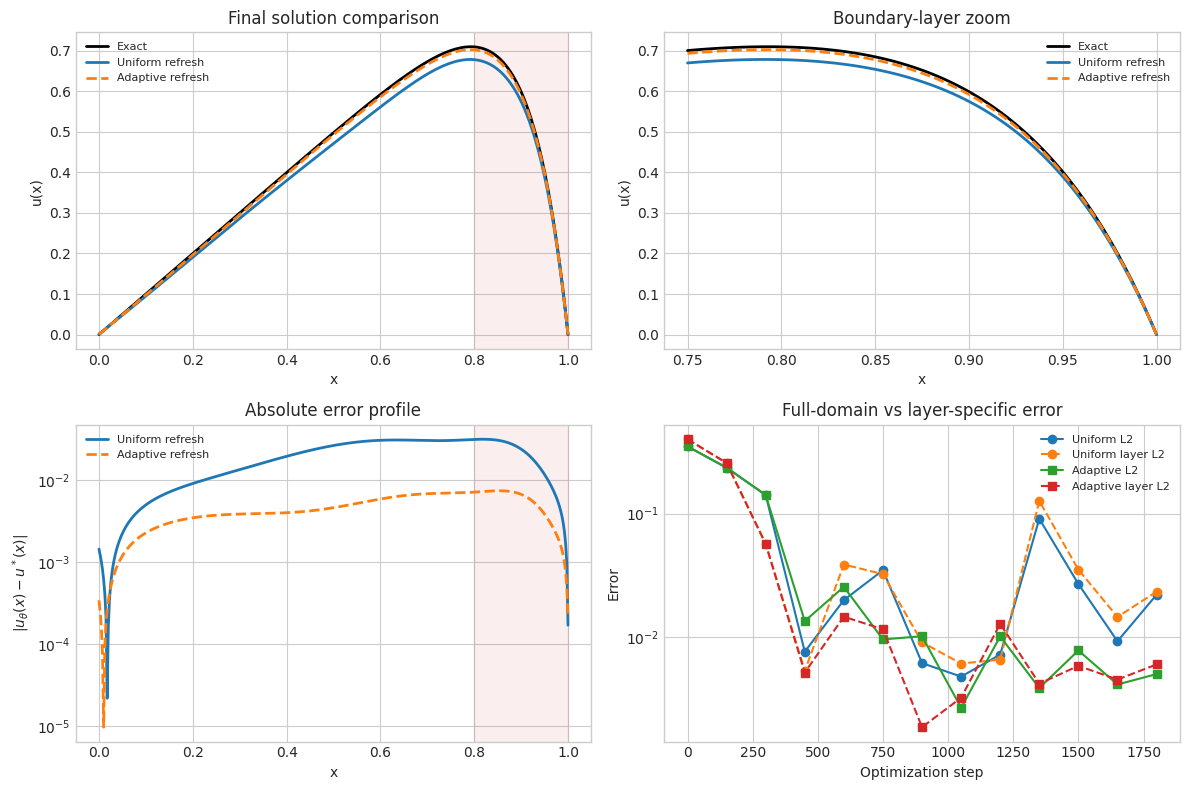

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(uniform_fields["x"], uniform_fields["u_exact"], label="Exact", linewidth=2, color="black")
axes[0, 0].plot(uniform_fields["x"], uniform_fields["u_pred"], label="Uniform refresh", linewidth=2, color="tab:blue")
axes[0, 0].plot(adaptive_fields["x"], adaptive_fields["u_pred"], label="Adaptive refresh", linewidth=2, linestyle="--", color="tab:orange")
axes[0, 0].axvspan(0.8, 1.0, color="tab:red", alpha=0.08)
axes[0, 0].set_title("Final solution comparison")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("u(x)")
axes[0, 0].legend(fontsize=8)

zoom_mask = uniform_fields["x"] >= 0.75
axes[0, 1].plot(uniform_fields["x"][zoom_mask], uniform_fields["u_exact"][zoom_mask], label="Exact", linewidth=2, color="black")
axes[0, 1].plot(uniform_fields["x"][zoom_mask], uniform_fields["u_pred"][zoom_mask], label="Uniform refresh", linewidth=2, color="tab:blue")
axes[0, 1].plot(adaptive_fields["x"][zoom_mask], adaptive_fields["u_pred"][zoom_mask], label="Adaptive refresh", linewidth=2, linestyle="--", color="tab:orange")
axes[0, 1].set_title("Boundary-layer zoom")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("u(x)")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(uniform_fields["x"], uniform_fields["abs_error"], label="Uniform refresh", linewidth=2, color="tab:blue")
axes[1, 0].plot(adaptive_fields["x"], adaptive_fields["abs_error"], label="Adaptive refresh", linewidth=2, linestyle="--", color="tab:orange")
axes[1, 0].axvspan(0.8, 1.0, color="tab:red", alpha=0.08)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Absolute error profile")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel(r"$|u_\theta(x) - u^*(x)|$")
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(uniform_history["step"], uniform_history["l2_error"], "o-", label="Uniform L2")
axes[1, 1].plot(uniform_history["step"], uniform_history["layer_l2_error"], "o--", label="Uniform layer L2")
axes[1, 1].plot(adaptive_history["step"], adaptive_history["l2_error"], "s-", label="Adaptive L2")
axes[1, 1].plot(adaptive_history["step"], adaptive_history["layer_l2_error"], "s--", label="Adaptive layer L2")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Full-domain vs layer-specific error")
axes[1, 1].set_xlabel("Optimization step")
axes[1, 1].set_ylabel("Error")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

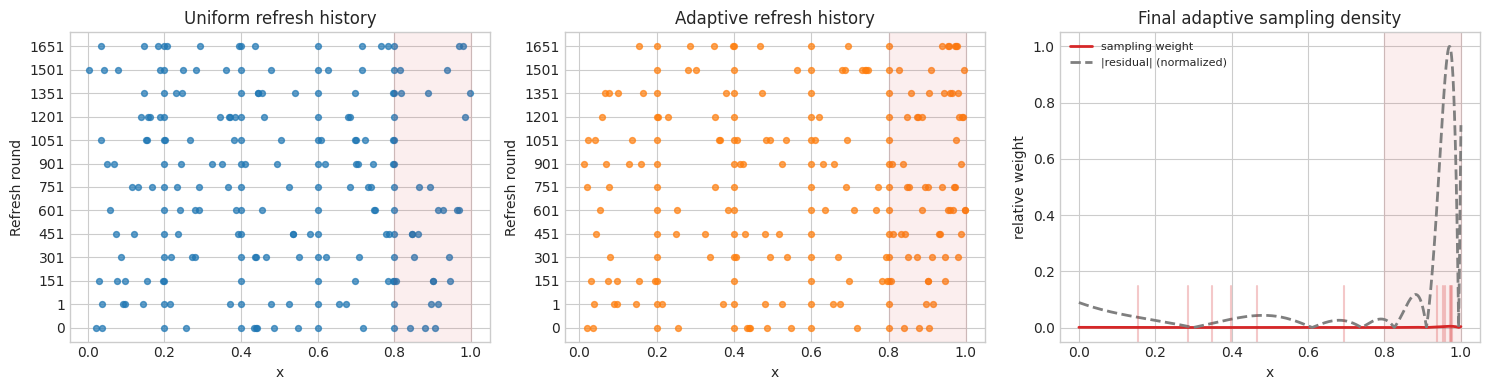

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for row, points in enumerate(uniform_history["x_points"]):
    axes[0].scatter(points, np.full_like(points, row, dtype=float), s=18, color="tab:blue", alpha=0.7)
axes[0].axvspan(0.8, 1.0, color="tab:red", alpha=0.08)
axes[0].set_title("Uniform refresh history")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Refresh round")
axes[0].set_yticks(np.arange(len(uniform_history["refresh_step"])))
axes[0].set_yticklabels(uniform_history["refresh_step"])

for row, points in enumerate(adaptive_history["x_points"]):
    axes[1].scatter(points, np.full_like(points, row, dtype=float), s=18, color="tab:orange", alpha=0.7)
axes[1].axvspan(0.8, 1.0, color="tab:red", alpha=0.08)
axes[1].set_title("Adaptive refresh history")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Refresh round")
axes[1].set_yticks(np.arange(len(adaptive_history["refresh_step"])))
axes[1].set_yticklabels(adaptive_history["refresh_step"])

sampling = adaptive_history["last_sampling"]
axes[2].plot(sampling["candidate_x"], sampling["weights"], color="tab:red", linewidth=2, label="sampling weight")
axes[2].plot(
    sampling["candidate_x"],
    sampling["residual_abs"] / np.max(sampling["residual_abs"]),
    color="tab:gray",
    linewidth=2,
    linestyle="--",
    label="|residual| (normalized)",
)
for x_value in sampling["sampled_x"]:
    axes[2].axvline(x_value, ymin=0.0, ymax=0.18, color="tab:red", alpha=0.25)
axes[2].axvspan(0.8, 1.0, color="tab:red", alpha=0.08)
axes[2].set_title("Final adaptive sampling density")
axes[2].set_xlabel("x")
axes[2].set_ylabel("relative weight")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Interpretation

In this fixed-seed run, the adaptive sampler spends the same `16`-point interior budget much more effectively than uniform refresh. The full-domain L2 error drops from roughly `2.19e-02` to `4.98e-03`, and the mean absolute residual drops from roughly `6.56e-01` to `2.18e-01`.

The point evolution plots explain why. Uniform refresh keeps distributing points broadly across the whole interval, while the adaptive sampler gradually pushes more of its flexible points toward the right boundary layer where the residual stays large. That is exactly the intended behavior.

This does not mean adaptive sampling is magic. We still needed a warmup phase and anchor points to keep the problem well conditioned. The main lesson is narrower and more practical: **when the hard region is spatially localized, sampling policy can matter as much as another small architecture tweak.**

## Key Takeaways

- Residual-based adaptive sampling reallocates a fixed collocation budget toward the regions where the PDE is currently hardest to satisfy.
- To study sampling policy cleanly, it is better here to compare two **refreshing** samplers than to compare against a fixed 1D grid.
- A small set of anchor points helps prevent adaptive sampling from forgetting the rest of the domain.
- RBAS is especially useful when the solution difficulty is localized, such as a boundary layer or a sharp interior feature.

## Next Step

Notebook `06` will keep the theme of “where standard PINNs break,” but move from sampling to representation. Adaptive sampling can help when the hard region is localized in space. The next notebook asks a different question: what if the solution itself contains multiple scales that a plain MLP struggles to represent everywhere?